# Matching inference

In [2]:
import pandas as pd
# Load data into pandas DataFrame from "/lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high/cohort_dynamic.csv"
df = pd.read_csv("/lakehouse/default/Files/output/inference/matching_high/calendar2_1year_high/cohort_dynamic.csv")
display(df)


StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 4, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 031eb6f2-09c7-4b50-aaf0-9faaaff2fe25)

In [3]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 5, Finished, Available, Finished, False)

In [4]:
%run ./matching_inference

StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 6, Finished, Available, Finished, True)

## Load Data 

### Adopt matching result

In [3]:
# Change here !!!
match_method = "calendar2"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)
# df
# df["top3_mean_consumption"] = pd.to_numeric(df["top3_mean_consumption"], errors="coerce")

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 5, Finished, Available, Finished, False)

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 6, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se   t_stat  p_value  \
0          -35        4.7303        4.6489  0.0814 0.2375   0.3427   0.7318   
1          -34        4.7393        4.8257 -0.0864 0.1667  -0.5183   0.6042   
2          -33        4.7656        4.8125 -0.0469 0.1590  -0.2950   0.7680   
3          -32        4.8386        4.9305 -0.0919 0.1882  -0.4880   0.6255   
4          -31        4.7643        4.6396  0.1246 0.2472   0.5043   0.6141   
5          -30        4.7971        4.5841  0.2130 0.2504   0.8506   0.3950   
6          -29        4.4810        4.5128 -0.0318 0.1809  -0.1757   0.8605   
7          -28        4.4976        4.4628  0.0348 0.1493   0.2328   0.8159   
8          -27        4.4471        4.3929  0.0542 0.1086   0.4993   0.6176   
9          -26        4.5971        4.5969  0.0002 0.0784   0.0027   0.9978   
10         -25        4.7440        4.7159  0.0281 0.0828   0.3390   0.7346   


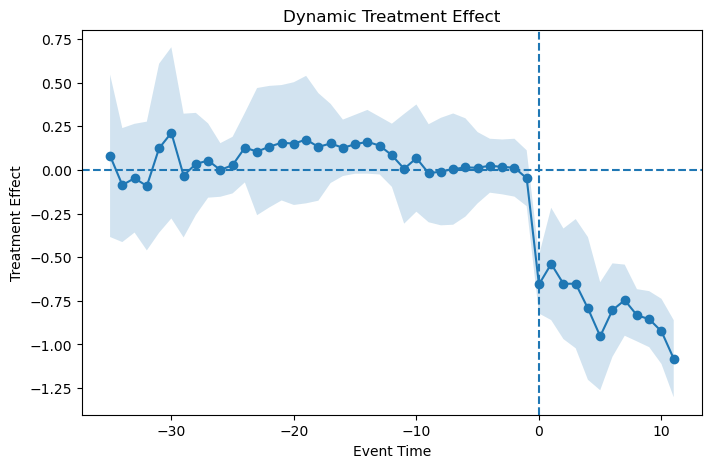


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.014416584873085133, 't_stat': 1.4259363903237825, 'p_value': 0.18164336887178653}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.7907281345304371, 'SE': 0.044152388483747945, 't_stat': -17.909068154296936, 'p_value': 0.0, 'CI_low': -0.877266815958583, 'CI_high': -0.7041894531022912, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.6155973799211084, 'SE': 0.038611226804986416, 't_stat': -15.943481491285006, 'p_value': 0.0, 'CI_low': -0.6912753844588818, 'CI_high': -0.539919375383335, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26 -0.0914 0.1045 -0.8749   0.3816        620   
1    2025-03         -25  0.0366 0.1076  0.3397   0.7340        620   
2    2025-03         -24  0.1234 0.1132  1.0897   0.2758        617   
3    2025-03        

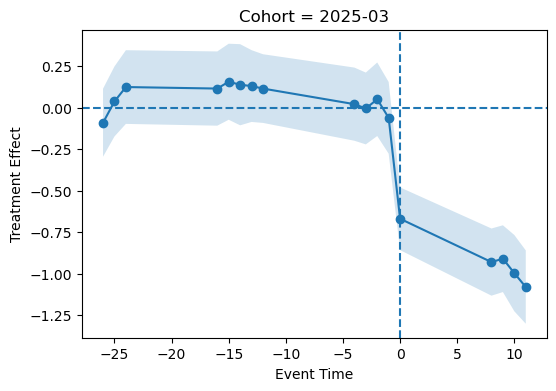

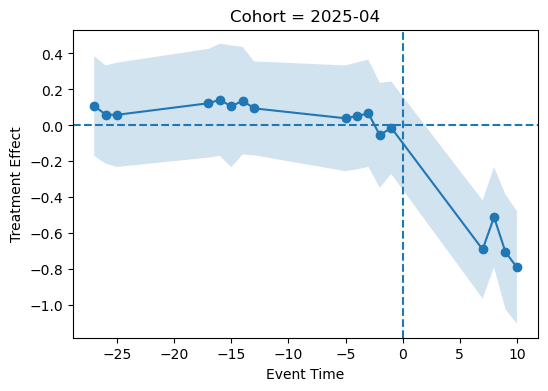

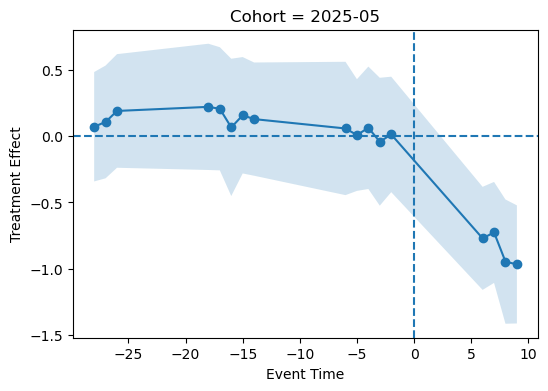

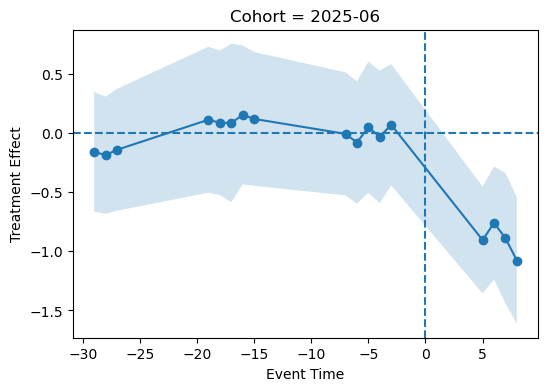

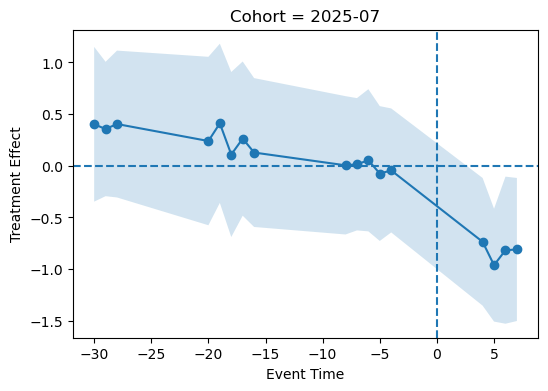

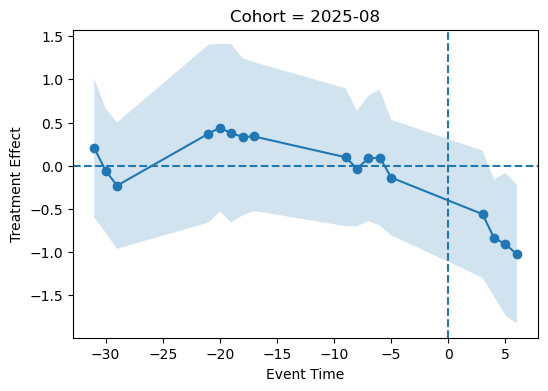

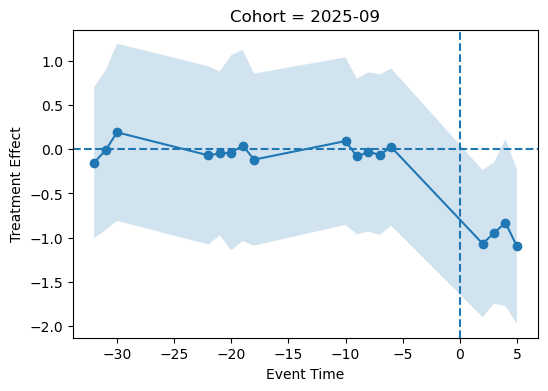

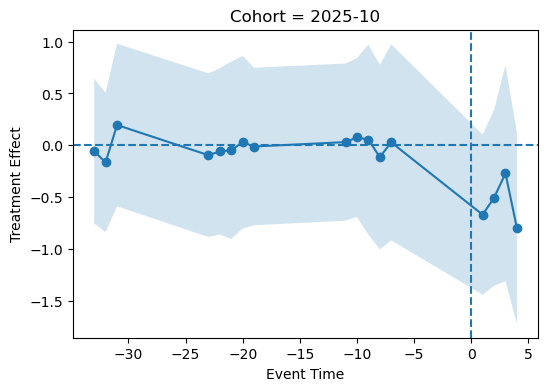

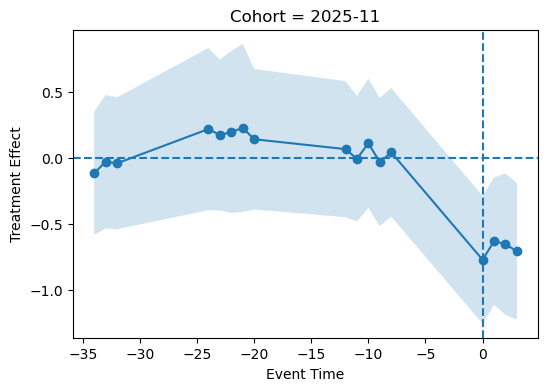

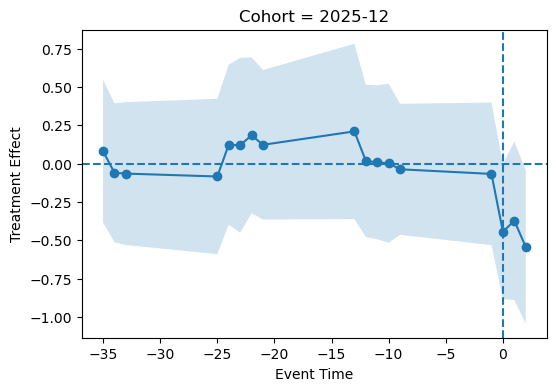

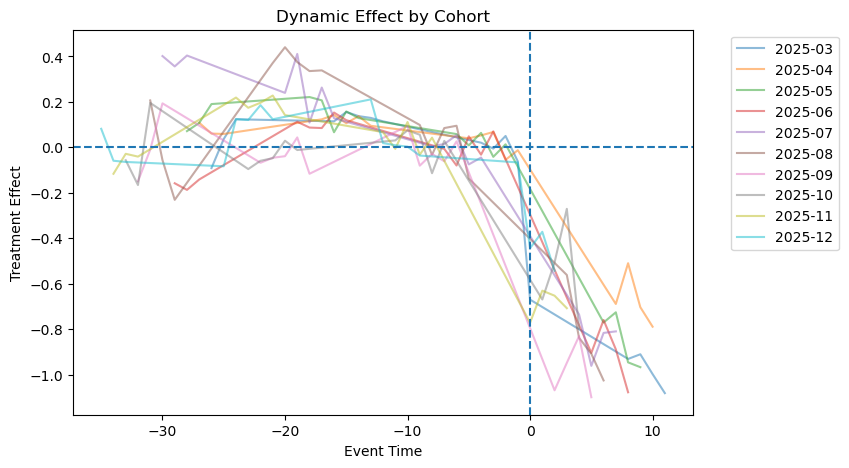


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.9183 0.0689 -13.3368   0.0000 -1.0532  -0.7833          5
1  2025-04 -0.6730 0.0587 -11.4744   0.0000 -0.7880  -0.5581          4
2  2025-05 -0.8526 0.0610 -13.9782   0.0000 -0.9722  -0.7331          4
3  2025-06 -0.9079 0.0653 -13.9045   0.0000 -1.0359  -0.7799          4
4  2025-07 -0.8310 0.0473 -17.5822   0.0000 -0.9236  -0.7383          4
5  2025-08 -0.8336 0.0985  -8.4610   0.0000 -1.0267  -0.6405          4
6  2025-09 -0.9869 0.0615 -16.0461   0.0000 -1.1075  -0.8664          4
7  2025-10 -0.5612 0.1136  -4.9395   0.0000 -0.7839  -0.3385          4
8  2025-11 -0.6909 0.0315 -21.9407   0.0000 -0.7526  -0.6291          4
9  2025-12 -0.4530 0.0497  -9.1088   0.0000 -0.5504  -0.3555          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-10 -0.5881 0.0814  -7.2279   0.000

In [4]:
df_high = df[df["price"]== "high"] 
results_high = run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 7, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.4359        5.3042  0.1318 0.2690  0.4898   0.6243   
1          -34        5.8549        5.4856  0.3693 0.2136  1.7287   0.0839   
2          -33        5.9161        5.4429  0.4732 0.2001  2.3645   0.0181   
3          -32        5.6449        5.2569  0.3881 0.1891  2.0516   0.0402   
4          -31        5.3000        4.7929  0.5070 0.1767  2.8688   0.0041   
5          -30        5.0478        4.4694  0.5784 0.1610  3.5939   0.0003   
6          -29        5.1316        4.4752  0.6564 0.1510  4.3463   0.0000   
7          -28        5.0651        4.5033  0.5618 0.1283  4.3801   0.0000   
8          -27        5.2364        4.5844  0.6521 0.1065  6.1206   0.0000   
9          -26        5.7963        4.9411  0.8551 0.0877  9.7470   0.0000   
10         -25        5.9034        4.9913  0.9122 0.0912 10.0027   0.0000   
11         -

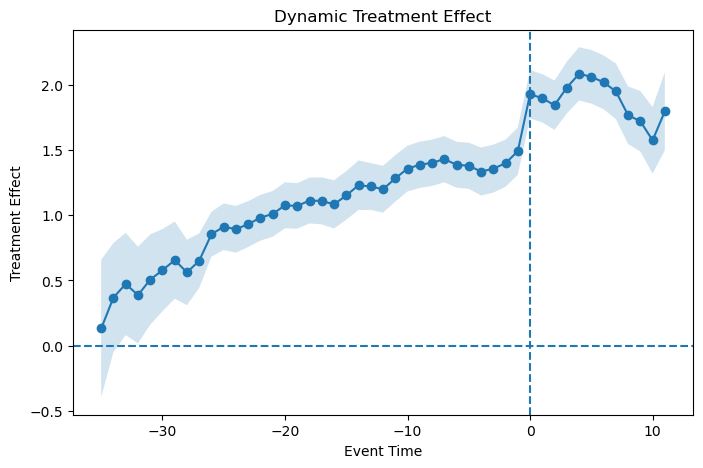


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.3680634829651261, 't_stat': 64.60961278180179, 'p_value': 1.5134761058334089e-15}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.8862092064592293, 'SE': 0.043599403220740046, 't_stat': 43.262271203794086, 'p_value': 0.0, 'CI_low': 1.8007543761465787, 'CI_high': 1.9716640367718798, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.8905581385811552, 'SE': 0.024690922713913106, 't_stat': 76.56895452982982, 'p_value': 0.0, 'CI_low': 1.8421639300618855, 'CI_high': 1.9389523471004249, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  1.0742 0.1467  7.3203   0.0000        620   
1    2025-03         -25  1.2445 0.1507  8.2592   0.0000        620   
2    2025-03         -24  1.2019 0.1517  7.9216   0.0000        617   
3    2025-03         -23  1

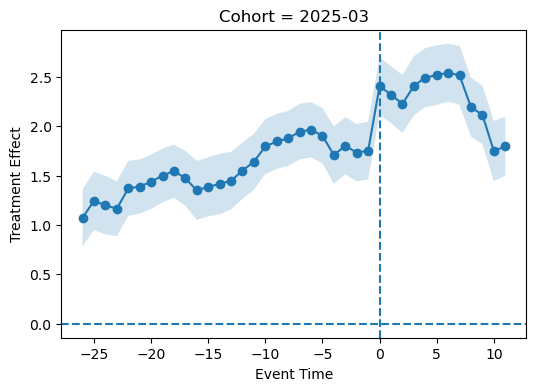

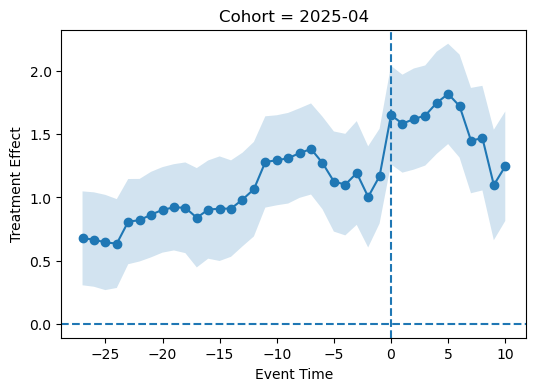

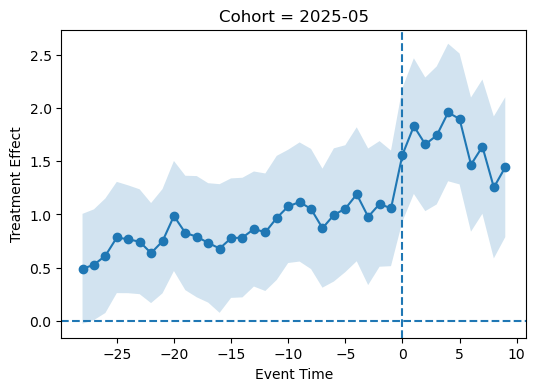

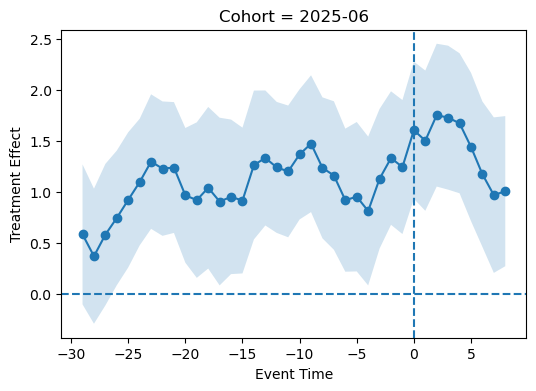

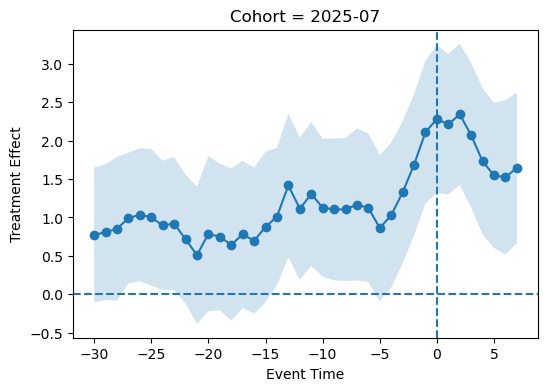

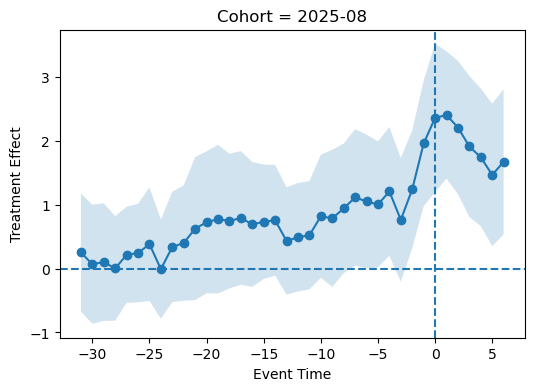

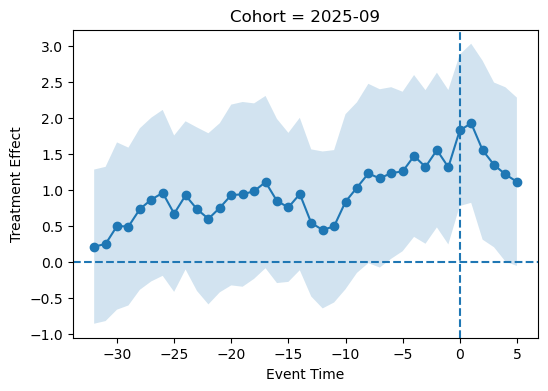

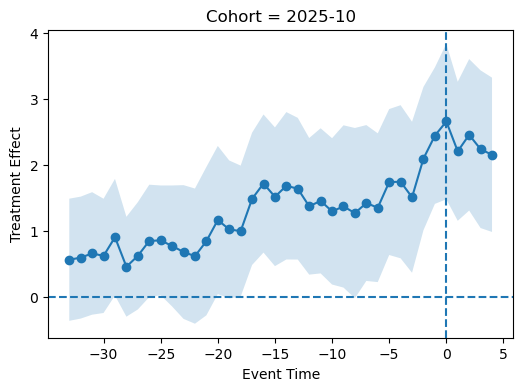

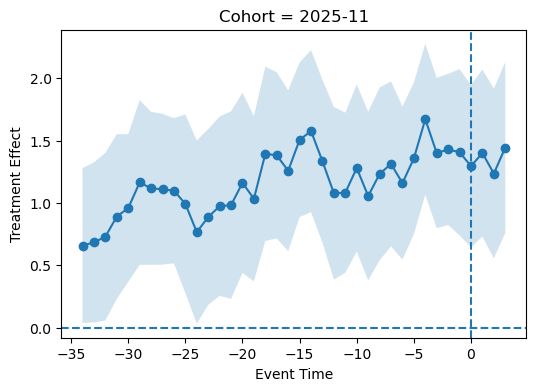

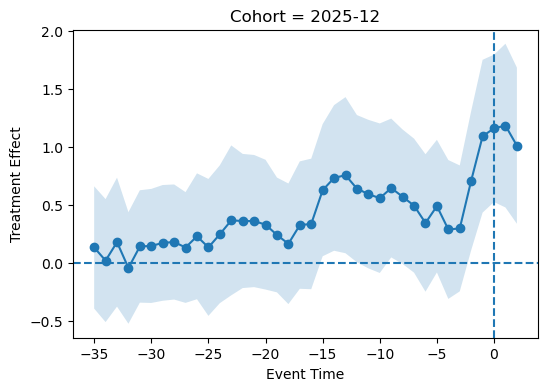

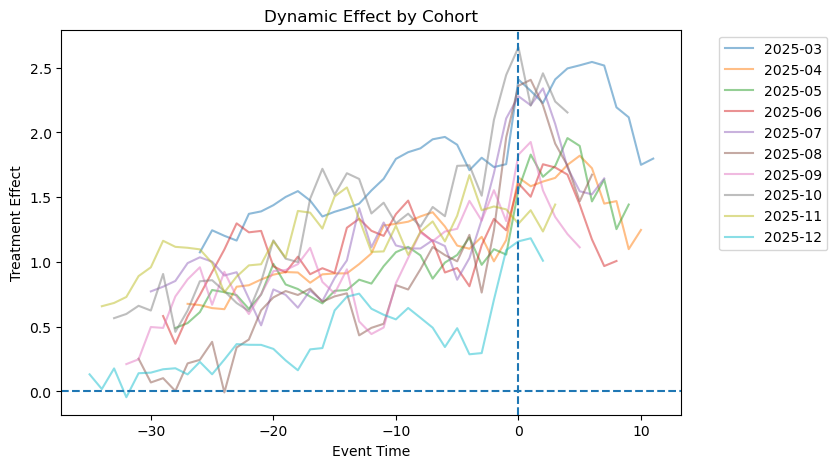


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2753 0.0785 28.9780   0.0000  2.1214   2.4292         12
1  2025-04 1.5516 0.0661 23.4577   0.0000  1.4220   1.6813         11
2  2025-05 1.6441 0.0696 23.6102   0.0000  1.5076   1.7805         10
3  2025-06 1.4290 0.1020 14.0074   0.0000  1.2290   1.6289          9
4  2025-07 1.9174 0.1212 15.8201   0.0000  1.6799   2.1550          8
5  2025-08 1.9683 0.1376 14.3042   0.0000  1.6986   2.2380          7
6  2025-09 1.4972 0.1350 11.0921   0.0000  1.2327   1.7618          6
7  2025-10 2.3433 0.0941 24.8913   0.0000  2.1588   2.5279          5
8  2025-11 1.3433 0.0476 28.2363   0.0000  1.2501   1.4366          4
9  2025-12 1.1170 0.0542 20.5961   0.0000  1.0107   1.2233          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.3195 0.0523 44.3658   0.0000  2.2170   2.4219        

In [5]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 8, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.1893        5.0196  0.1698 0.2637  0.6439   0.5196   
1          -34        5.5685        5.1743  0.3943 0.2125  1.8558   0.0635   
2          -33        5.6504        5.1137  0.5366 0.1994  2.6916   0.0071   
3          -32        5.4765        5.0622  0.4144 0.1869  2.2171   0.0266   
4          -31        5.2005        4.6864  0.5141 0.1755  2.9297   0.0034   
5          -30        4.9566        4.3708  0.5858 0.1592  3.6802   0.0002   
6          -29        5.0454        4.3631  0.6823 0.1504  4.5373   0.0000   
7          -28        4.9649        4.3716  0.5934 0.1277  4.6451   0.0000   
8          -27        5.1166        4.4181  0.6985 0.1060  6.5883   0.0000   
9          -26        5.6511        4.7522  0.8989 0.0874 10.2802   0.0000   
10         -25        5.7639        4.7898  0.9741 0.0910 10.7051   0.0000   
11         -

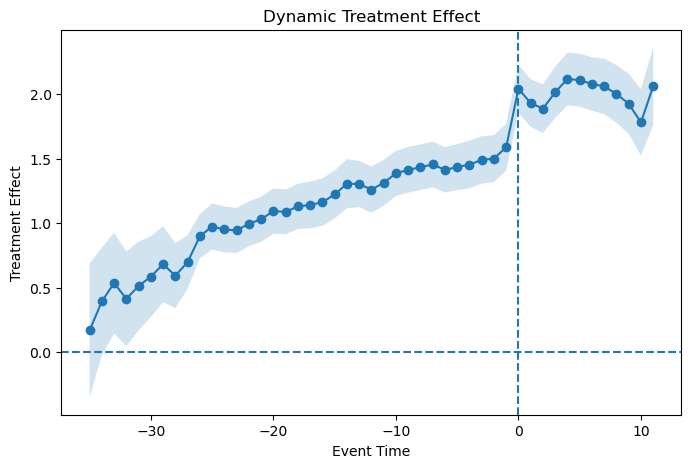


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.4277649838246234, 't_stat': 57.97103009247484, 'p_value': 4.971874000722516e-15}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.999226287447673, 'SE': 0.029113016097456583, 't_stat': 68.67121842529852, 'p_value': 0.0, 'CI_low': 1.942164775896658, 'CI_high': 2.056287798998688, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.9518211302189996, 'SE': 0.045845944606588654, 't_stat': 42.57347398920204, 'p_value': 0.0, 'CI_low': 1.8619630787900858, 'CI_high': 2.0416791816479134, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  1.1850 0.1474  8.0411   0.0000        620   
1    2025-03         -25  1.3604 0.1513  8.9911   0.0000        620   
2    2025-03         -24  1.3405 0.1531  8.7555   0.0000        617   
3    2025-03         -23  1.1652

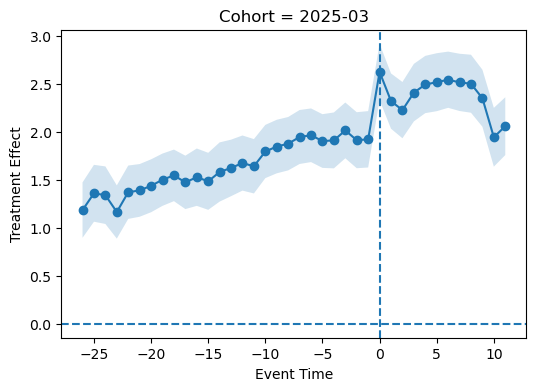

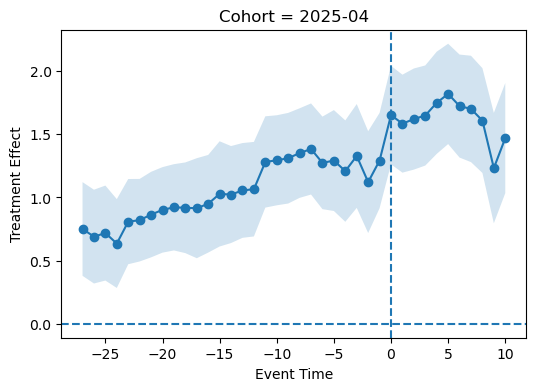

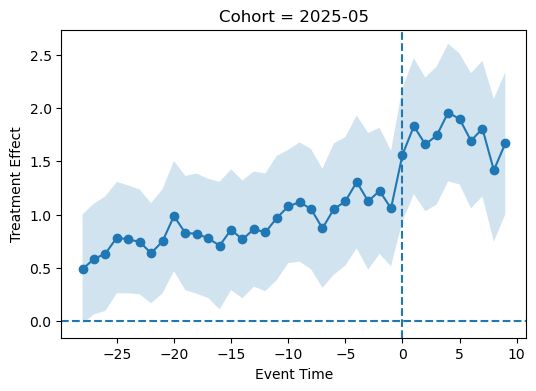

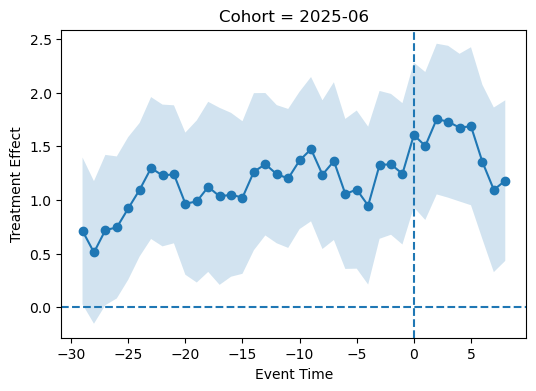

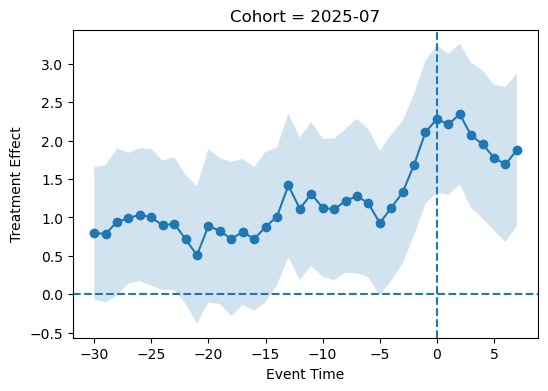

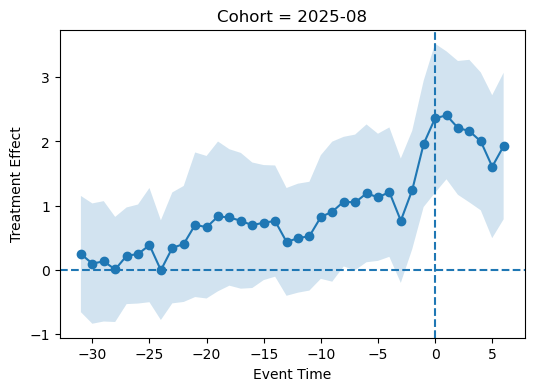

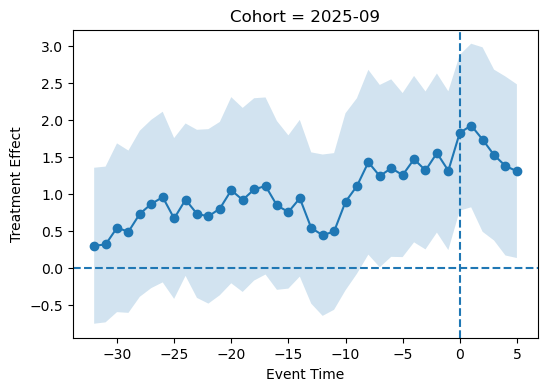

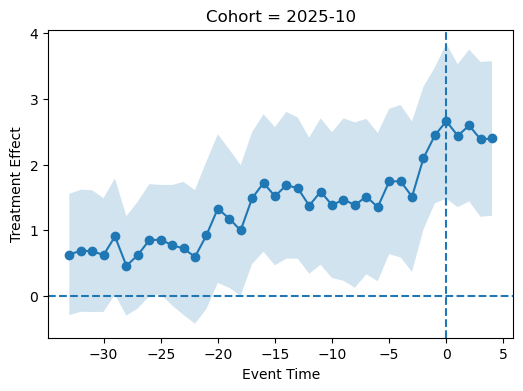

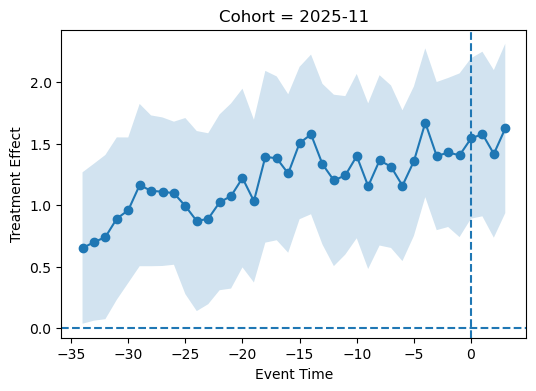

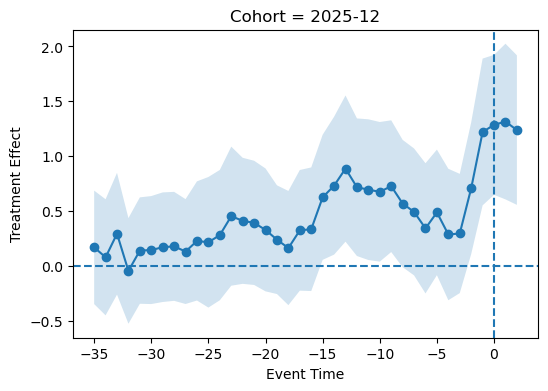

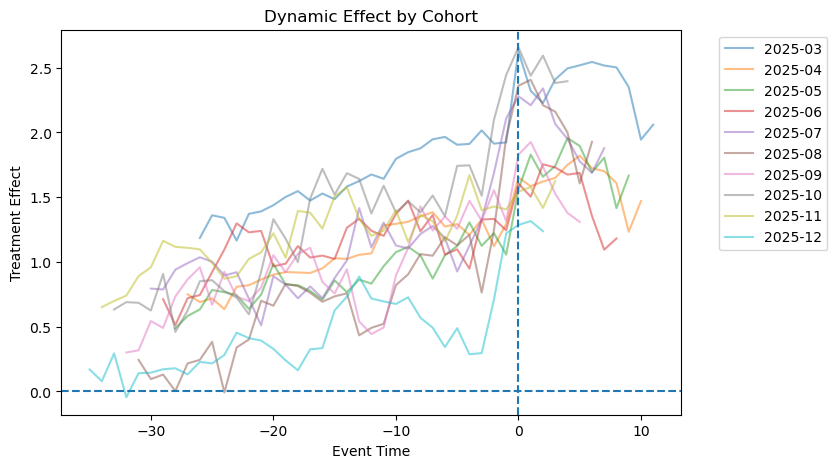


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.3767 0.0599 39.6599   0.0000  2.2592   2.4942         12
1  2025-04 1.6195 0.0477 33.9630   0.0000  1.5260   1.7129         11
2  2025-05 1.7220 0.0509 33.8576   0.0000  1.6223   1.8217         10
3  2025-06 1.5097 0.0817 18.4788   0.0000  1.3496   1.6699          9
4  2025-07 2.0240 0.0848 23.8704   0.0000  1.8578   2.1902          8
5  2025-08 2.0962 0.1048 19.9965   0.0000  1.8908   2.3017          7
6  2025-09 1.6178 0.1024 15.8018   0.0000  1.4171   1.8185          6
7  2025-10 2.4938 0.0558 44.7204   0.0000  2.3845   2.6031          5
8  2025-11 1.5405 0.0444 34.6852   0.0000  1.4535   1.6276          4
9  2025-12 1.2795 0.0226 56.5730   0.0000  1.2352   1.3239          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.3920 0.1203 19.8883   0.0000  2.1562   2.6277        

In [6]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")

In [5]:
# Change here !!!
match_method = "calendar2_1year"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 7, Finished, Available, Finished, False)

StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 9, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se   t_stat  p_value  \
0          -35        4.7303        4.2732  0.4571 0.2317   1.9724   0.0486   
1          -34        4.7393        4.5298  0.2095 0.1618   1.2949   0.1953   
2          -33        4.7656        4.5892  0.1764 0.1559   1.1320   0.2576   
3          -32        4.8386        4.7645  0.0741 0.1845   0.4018   0.6879   
4          -31        4.7643        4.5564  0.2078 0.2456   0.8464   0.3973   
5          -30        4.7971        4.4840  0.3131 0.2479   1.2632   0.2065   
6          -29        4.4810        4.4412  0.0399 0.1789   0.2228   0.8237   
7          -28        4.4976        4.4521  0.0455 0.1479   0.3078   0.7583   
8          -27        4.4471        4.4178  0.0293 0.1080   0.2711   0.7863   
9          -26        4.5971        4.6132 -0.0162 0.0778  -0.2079   0.8353   
10         -25        4.7440        4.6669  0.0772 0.0820   0.9410   0.3467   


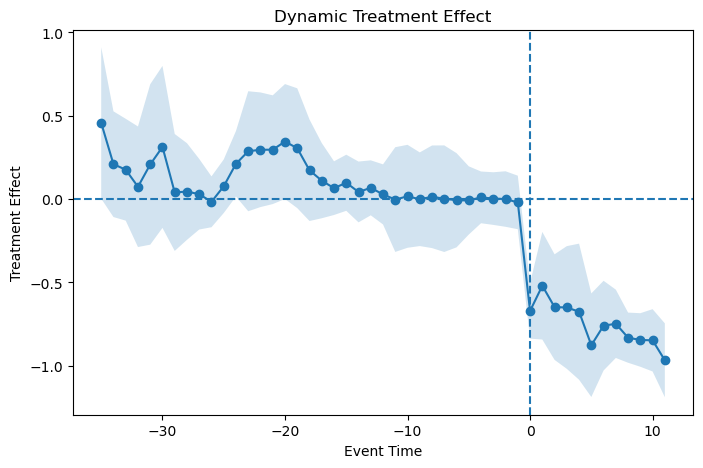


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.00313008181870833, 't_stat': 0.8464771590058758, 'p_value': 0.415322253435671}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.7532271644199527, 'SE': 0.03625140281769754, 't_stat': -20.77787632682274, 'p_value': 0.0, 'CI_low': -0.8242799139426399, 'CI_high': -0.6821744148972656, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.6128166853221249, 'SE': 0.04706289131514943, 't_stat': -13.021229002240682, 'p_value': 0.0, 'CI_low': -0.7050599522998178, 'CI_high': -0.5205734183444319, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26 -0.0425 0.1030 -0.4130   0.6796        620   
1    2025-03         -25  0.1051 0.1063  0.9884   0.3229        620   
2    2025-03         -24  0.1053 0.1122  0.9385   0.3480        617   
3    2025-03         -16

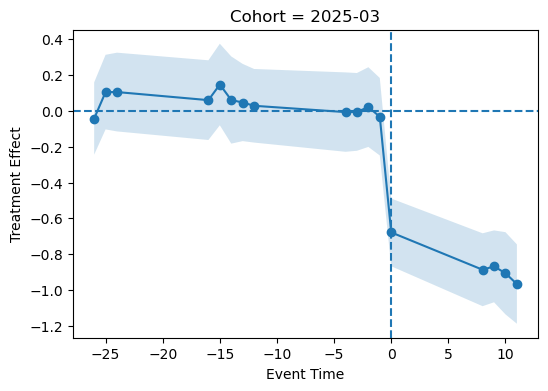

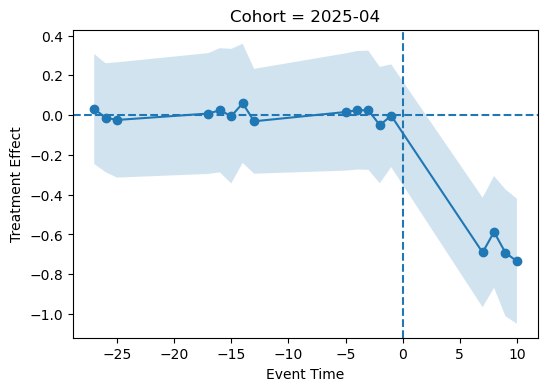

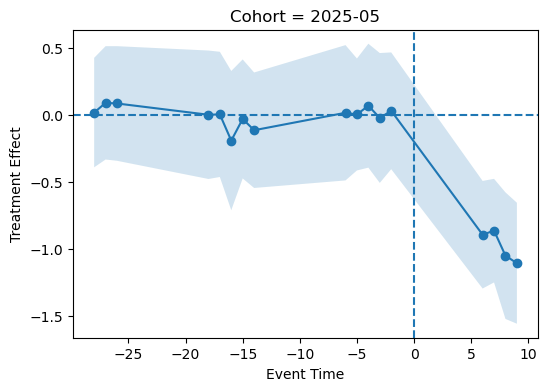

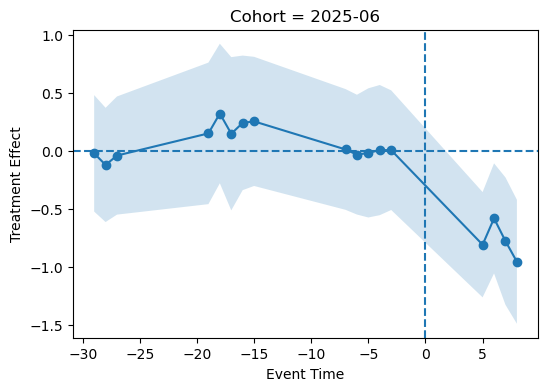

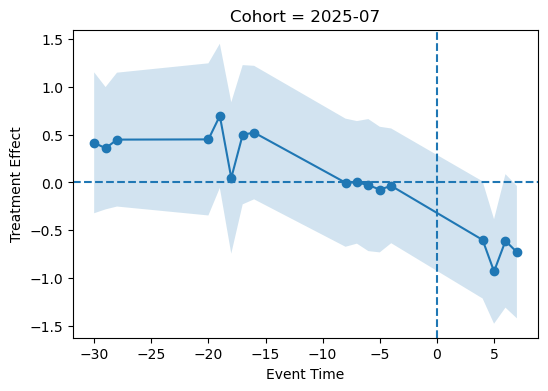

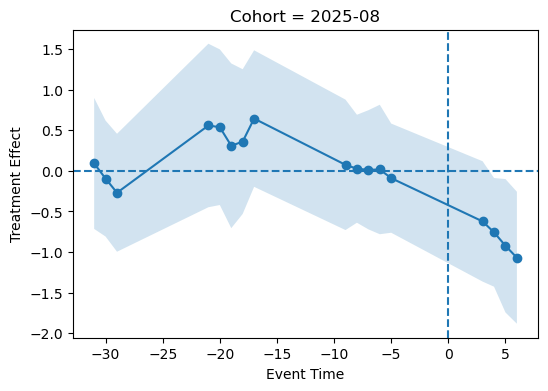

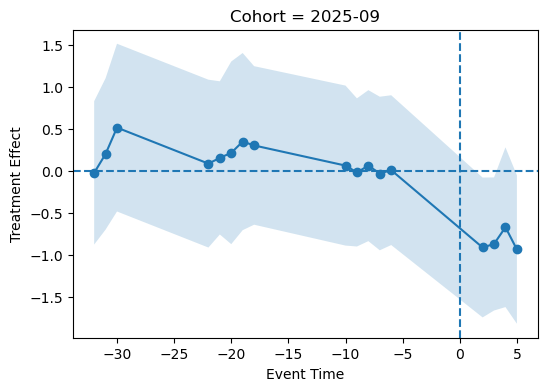

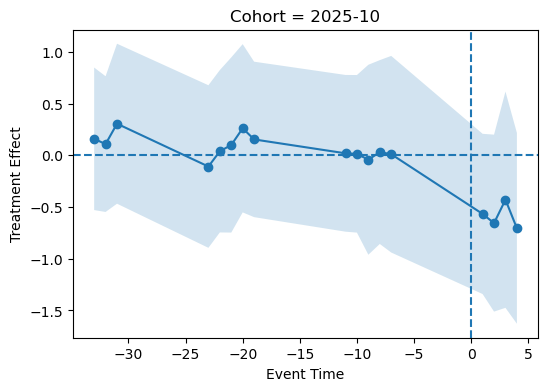

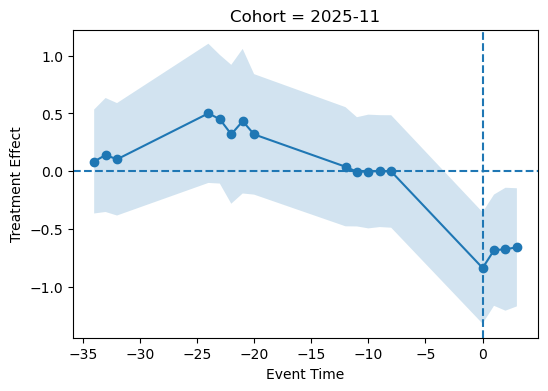

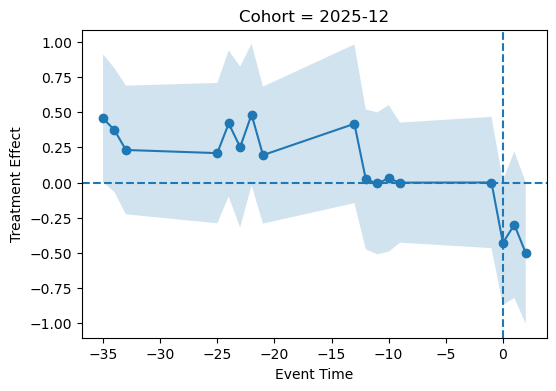

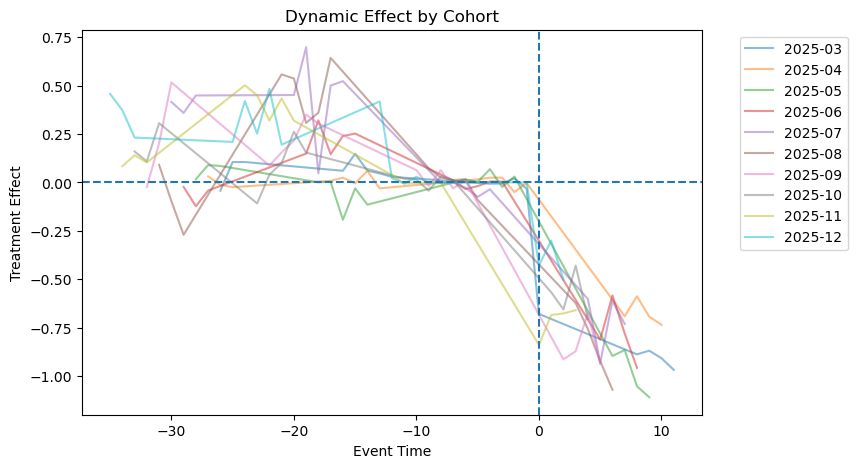


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8615 0.0487 -17.7016   0.0000 -0.9569  -0.7661          5
1  2025-04 -0.6761 0.0313 -21.5930   0.0000 -0.7375  -0.6148          4
2  2025-05 -0.9800 0.0592 -16.5589   0.0000 -1.0961  -0.8640          4
3  2025-06 -0.7822 0.0768 -10.1804   0.0000 -0.9327  -0.6316          4
4  2025-07 -0.7188 0.0767  -9.3664   0.0000 -0.8692  -0.5684          4
5  2025-08 -0.8429 0.0972  -8.6690   0.0000 -1.0335  -0.6523          4
6  2025-09 -0.8479 0.0605 -14.0201   0.0000 -0.9664  -0.7294          4
7  2025-10 -0.5891 0.0606  -9.7166   0.0000 -0.7079  -0.4702          4
8  2025-11 -0.7143 0.0416 -17.1751   0.0000 -0.7958  -0.6328          4
9  2025-12 -0.4102 0.0591  -6.9377   0.0000 -0.5261  -0.2943          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-10 -0.6110 0.0445 -13.7249   0.000

In [7]:
df_high = df[df["price"]== "high"] 
results_high =run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 10, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.4359        5.0079  0.4280 0.2656  1.6118   0.1070   
1          -34        5.8549        5.3201  0.5348 0.2107  2.5388   0.0111   
2          -33        5.9161        5.3357  0.5803 0.1981  2.9294   0.0034   
3          -32        5.6449        5.1886  0.4564 0.1879  2.4293   0.0151   
4          -31        5.3000        4.7715  0.5285 0.1760  3.0030   0.0027   
5          -30        5.0478        4.4452  0.6027 0.1599  3.7692   0.0002   
6          -29        5.1316        4.4548  0.6768 0.1501  4.5086   0.0000   
7          -28        5.0651        4.4952  0.5699 0.1275  4.4700   0.0000   
8          -27        5.2364        4.6337  0.6027 0.1062  5.6775   0.0000   
9          -26        5.7963        5.0140  0.7823 0.0873  8.9557   0.0000   
10         -25        5.9034        5.0492  0.8543 0.0909  9.3975   0.0000   
11         -

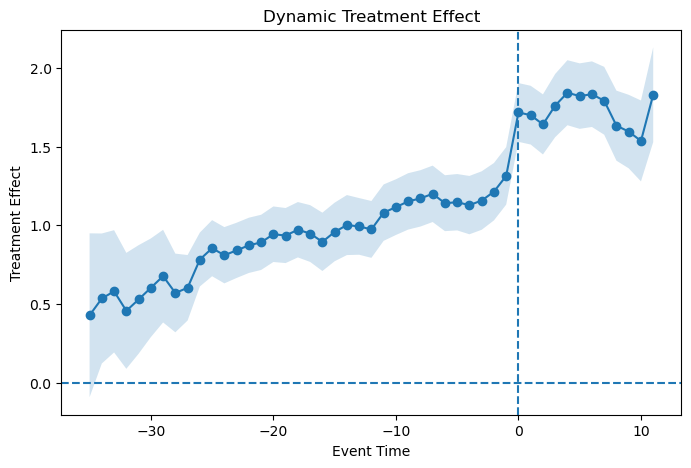


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.149012499507479, 't_stat': 49.37211701662592, 'p_value': 2.8894802832849106e-14}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.7246039073533643, 'SE': 0.030153561250205844, 't_stat': 57.194037315960195, 'p_value': 0.0, 'CI_low': 1.665502927302961, 'CI_high': 1.7837048874037678, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.685524924106768, 'SE': 0.02300478201429555, 't_stat': 73.26845883866038, 'p_value': 0.0, 'CI_low': 1.6404355513587487, 'CI_high': 1.7306142968547873, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  1.0239 0.1459  7.0197   0.0000        620   
1    2025-03         -25  1.1711 0.1503  7.7910   0.0000        620   
2    2025-03         -24  1.1020 0.1511  7.2910   0.0000        617   
3    2025-03         -23  1.040

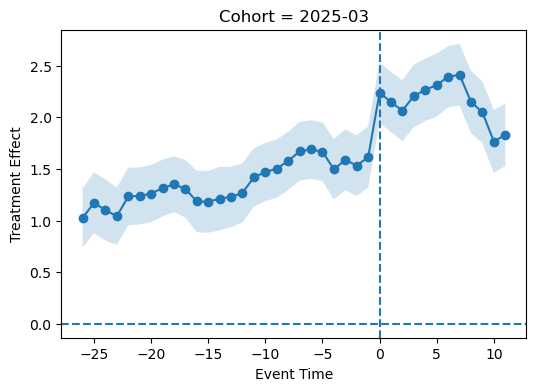

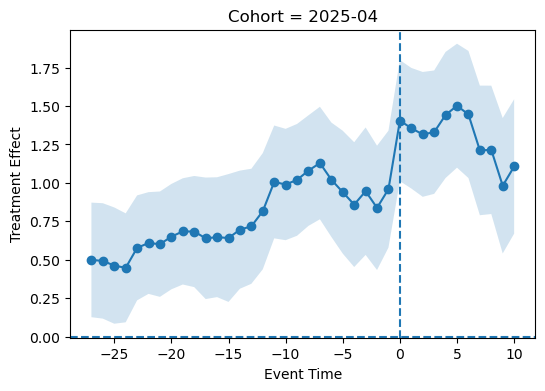

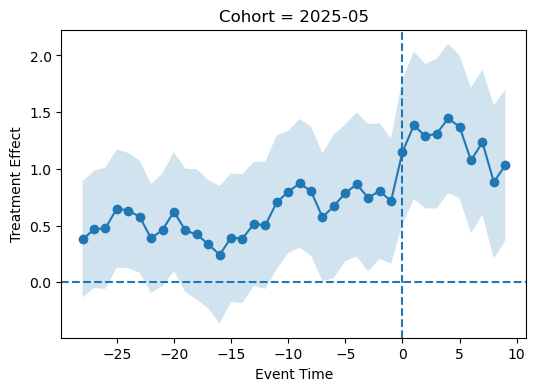

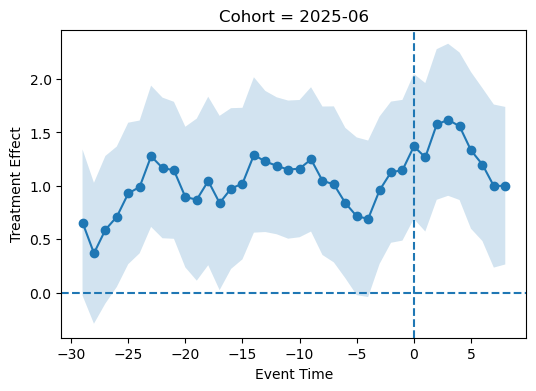

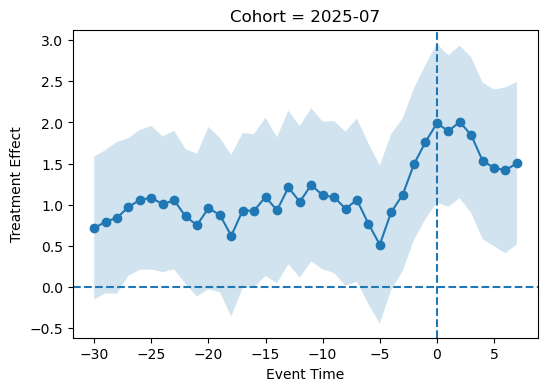

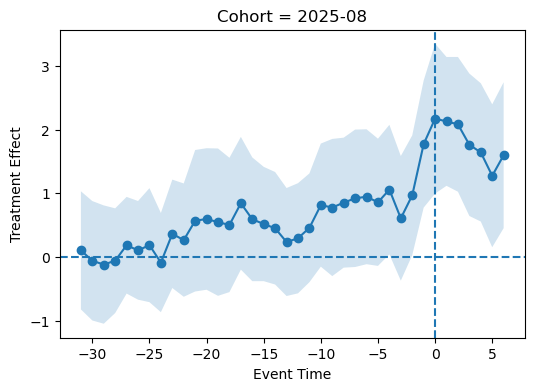

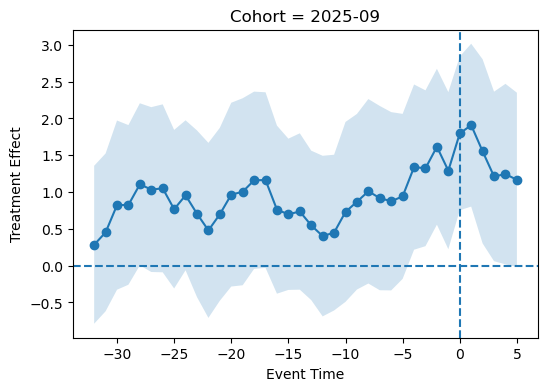

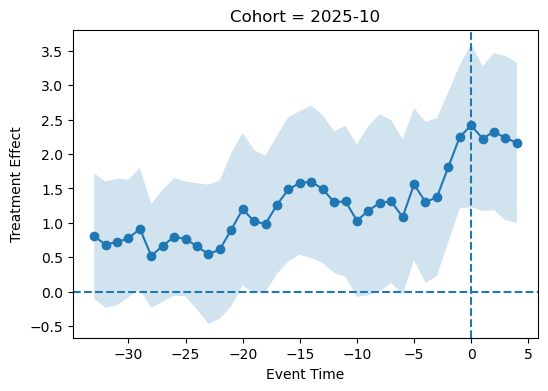

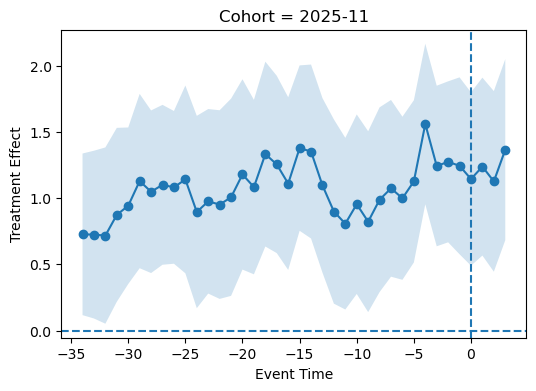

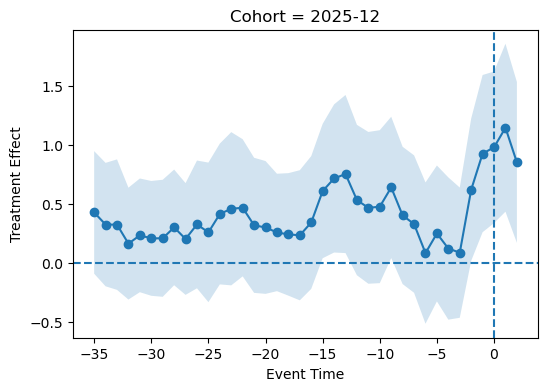

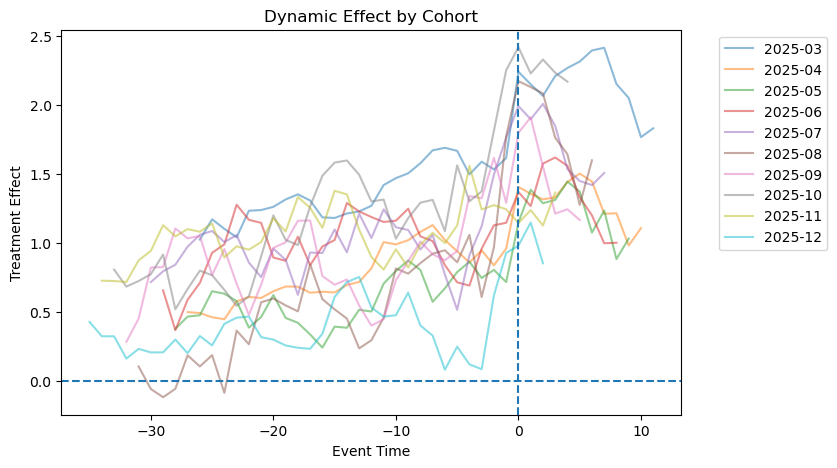


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.1531 0.0582 37.0094   0.0000  2.0391   2.2671         12
1  2025-04 1.3008 0.0478 27.2290   0.0000  1.2071   1.3944         11
2  2025-05 1.2172 0.0566 21.4980   0.0000  1.1062   1.3282         10
3  2025-06 1.3241 0.0778 17.0256   0.0000  1.1716   1.4765          9
4  2025-07 1.7057 0.0892 19.1256   0.0000  1.5309   1.8805          8
5  2025-08 1.8082 0.1260 14.3527   0.0000  1.5613   2.0551          7
6  2025-09 1.4800 0.1311 11.2909   0.0000  1.2230   1.7369          6
7  2025-10 2.2737 0.0439 51.7500   0.0000  2.1876   2.3598          5
8  2025-11 1.2181 0.0548 22.2296   0.0000  1.1107   1.3255          4
9  2025-12 0.9936 0.0853 11.6484   0.0000  0.8264   1.1608          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.1505 0.0503 42.7768   0.0000  2.0520   2.2490        

In [8]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, cb292542-1a91-48a9-ac86-7eda3c924e46, 11, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.1893        4.7426  0.4467 0.2608  1.7125   0.0868   
1          -34        5.5685        5.0340  0.5345 0.2100  2.5455   0.0109   
2          -33        5.6504        5.0285  0.6219 0.1977  3.1460   0.0017   
3          -32        5.4765        4.9859  0.4907 0.1856  2.6429   0.0082   
4          -31        5.2005        4.6569  0.5436 0.1747  3.1114   0.0019   
5          -30        4.9566        4.3438  0.6128 0.1581  3.8767   0.0001   
6          -29        5.0454        4.3418  0.7036 0.1495  4.7063   0.0000   
7          -28        4.9649        4.3593  0.6056 0.1269  4.7713   0.0000   
8          -27        5.1166        4.4616  0.6550 0.1057  6.1988   0.0000   
9          -26        5.6511        4.8196  0.8315 0.0870  9.5532   0.0000   
10         -25        5.7639        4.8518  0.9122 0.0907 10.0516   0.0000   
11         -

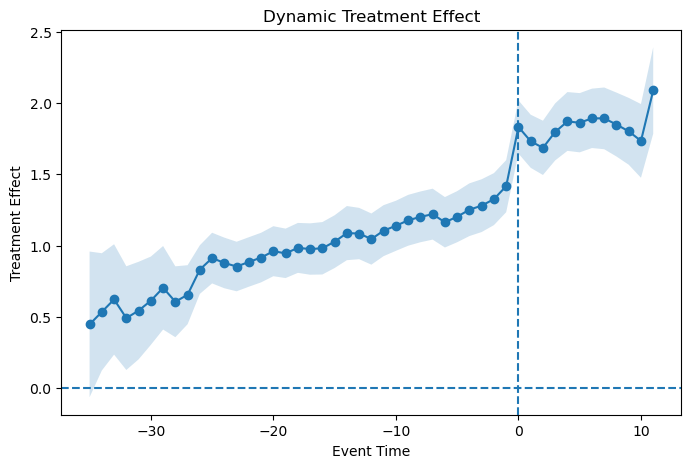


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.2107249196292251, 't_stat': 42.02964819822232, 'p_value': 1.6836258898193699e-13}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.8368429186878945, 'SE': 0.029977236403651995, 't_stat': 61.27459162526803, 'p_value': 0.0, 'CI_low': 1.7780875353367367, 'CI_high': 1.8955983020390523, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.7501763210604384, 'SE': 0.043273733313695315, 't_stat': 40.444310833392805, 'p_value': 0.0, 'CI_low': 1.6653598037655957, 'CI_high': 1.8349928383552812, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  1.1388 0.1464  7.7769   0.0000        620   
1    2025-03         -25  1.2752 0.1509  8.4482   0.0000        620   
2    2025-03         -24  1.2599 0.1526  8.2559   0.0000        617   
3    2025-03         -23  1

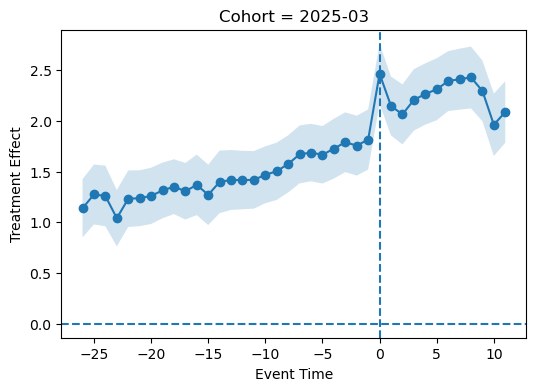

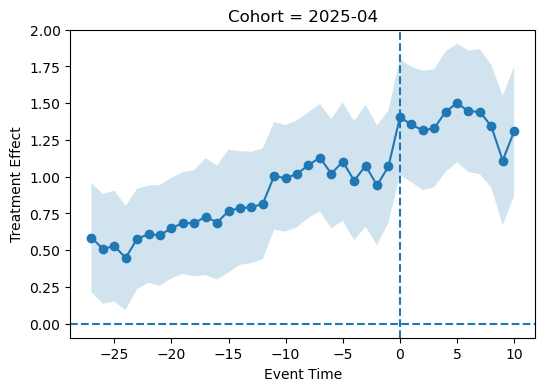

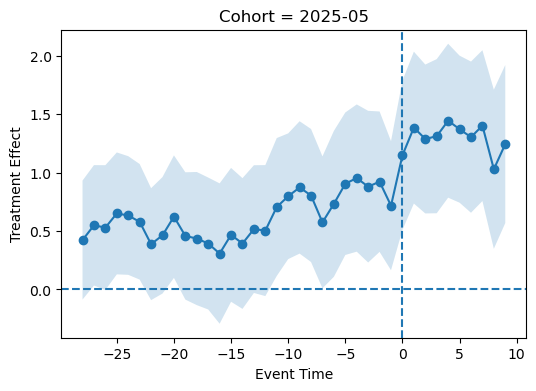

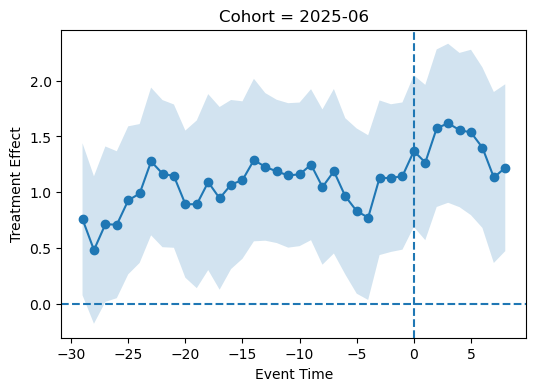

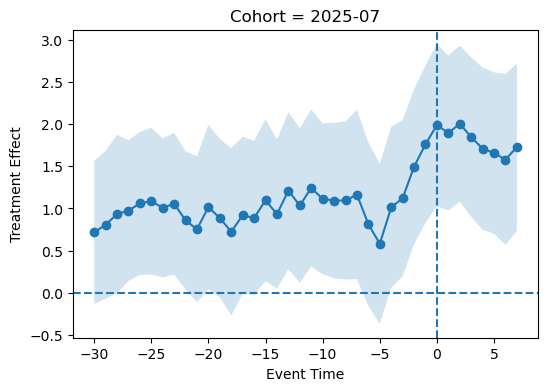

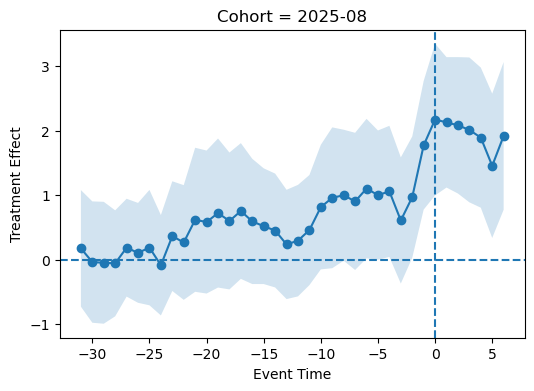

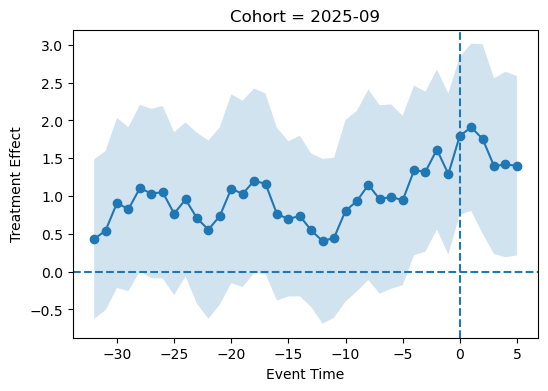

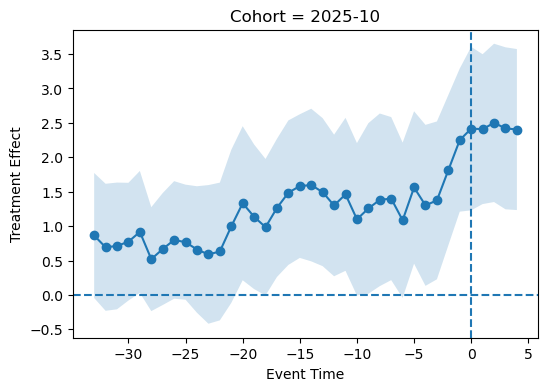

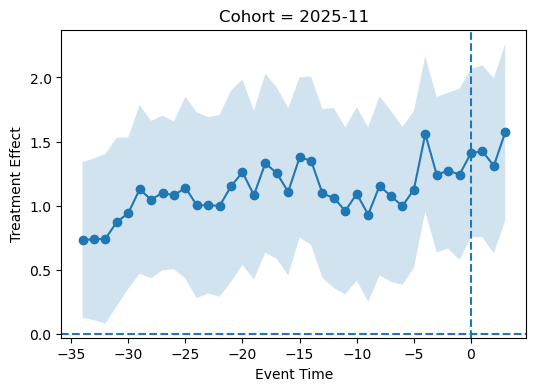

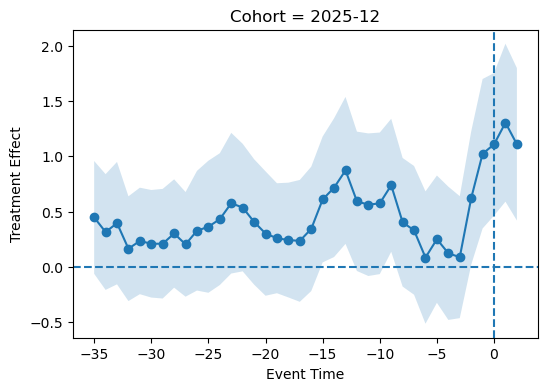

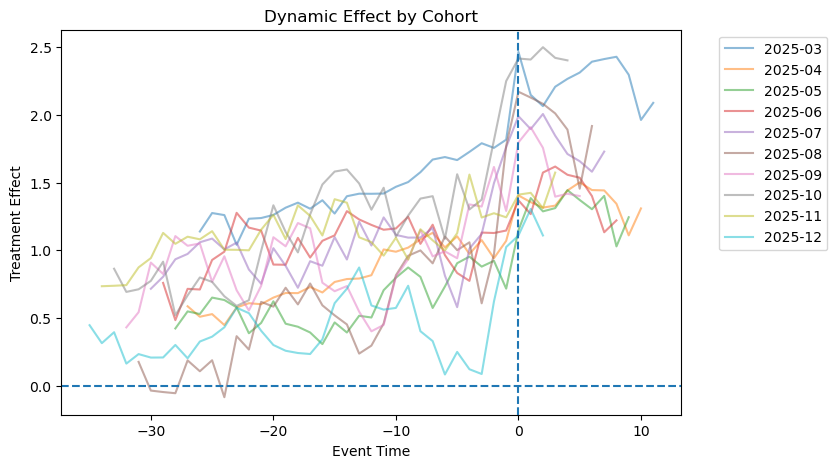


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2539 0.0466  48.3882   0.0000  2.1626   2.3452         12
1  2025-04 1.3636 0.0317  42.9714   0.0000  1.3014   1.4258         11
2  2025-05 1.2925 0.0399  32.4151   0.0000  1.2144   1.3707         10
3  2025-06 1.4085 0.0581  24.2566   0.0000  1.2947   1.5223          9
4  2025-07 1.8021 0.0553  32.5617   0.0000  1.6936   1.9106          8
5  2025-08 1.9507 0.0915  21.3308   0.0000  1.7715   2.1300          7
6  2025-09 1.6127 0.0952  16.9348   0.0000  1.4260   1.7993          6
7  2025-10 2.4297 0.0178 136.5455   0.0000  2.3948   2.4646          5
8  2025-11 1.4301 0.0541  26.4432   0.0000  1.3241   1.5362          4
9  2025-12 1.1746 0.0654  17.9674   0.0000  1.0465   1.3028          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 2.2259 0.1220 18.2457   0.0000  1.9868   2.4

In [9]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")

In [11]:
# Change here !!!
match_method = "summary_4"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching_high/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 13, Finished, Available, Finished, False)

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 14, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se   t_stat  p_value  \
0          -35        4.7303        4.4953  0.2350 0.2330   1.0087   0.3131   
1          -34        4.7393        4.6256  0.1137 0.1631   0.6972   0.4857   
2          -33        4.7656        4.6575  0.1082 0.1563   0.6918   0.4890   
3          -32        4.8386        4.8863 -0.0477 0.1855  -0.2569   0.7972   
4          -31        4.7643        4.5521  0.2122 0.2448   0.8667   0.3861   
5          -30        4.7971        4.5178  0.2793 0.2486   1.1238   0.2611   
6          -29        4.4810        4.3696  0.1115 0.1786   0.6242   0.5325   
7          -28        4.4976        4.4724  0.0252 0.1486   0.1694   0.8655   
8          -27        4.4471        4.3603  0.0868 0.1082   0.8026   0.4222   
9          -26        4.5971        4.4978  0.0993 0.0775   1.2812   0.2001   
10         -25        4.7440        4.5798  0.1642 0.0818   2.0069   0.0448   


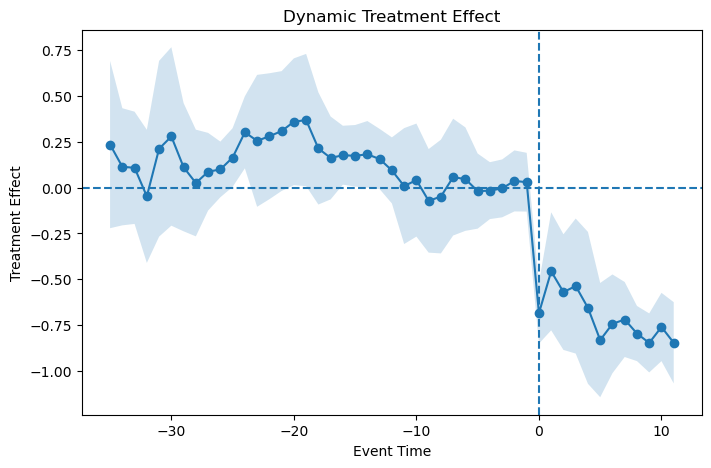


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.0127082469790795, 't_stat': 0.9317661166192872, 'p_value': 0.37145683351646774}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': -0.704601745849207, 'SE': 0.036989742321185966, 't_stat': -19.048571350702396, 'p_value': 0.0, 'CI_low': -0.7771016407987315, 'CI_high': -0.6321018508996825, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': -0.5708680388229963, 'SE': 0.06590599125981077, 't_stat': -8.661853465985415, 'p_value': 0.0, 'CI_low': -0.7000437816922254, 'CI_high': -0.44169229595376724, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  0.1343 0.1025  1.3112   0.1898        620   
1    2025-03         -25  0.2216 0.1059  2.0927   0.0364        620   
2    2025-03         -24  0.2829 0.1115  2.5379   0.0112        617   
3    2025-03         -

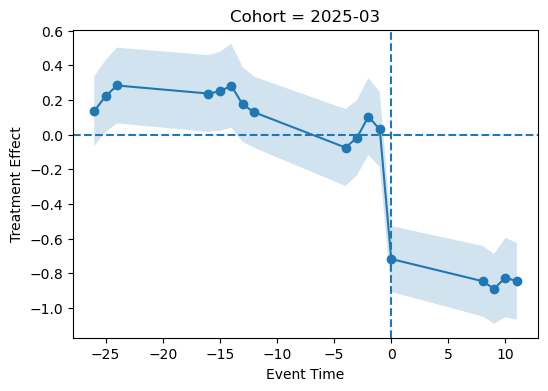

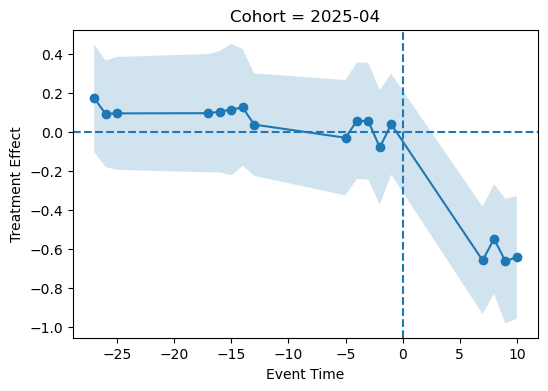

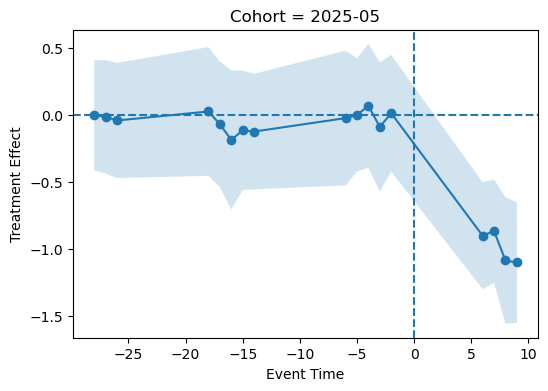

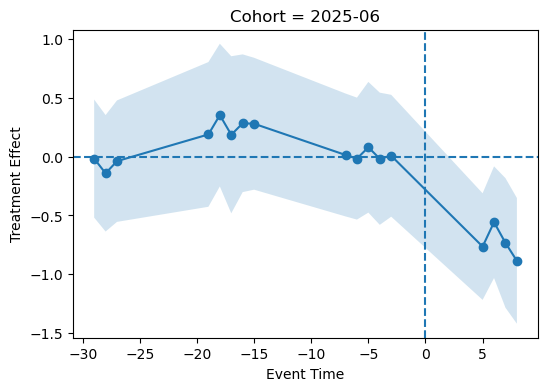

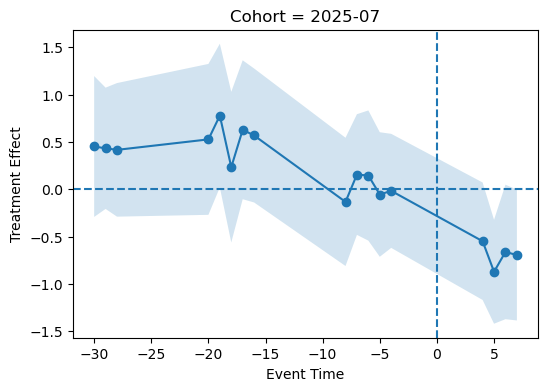

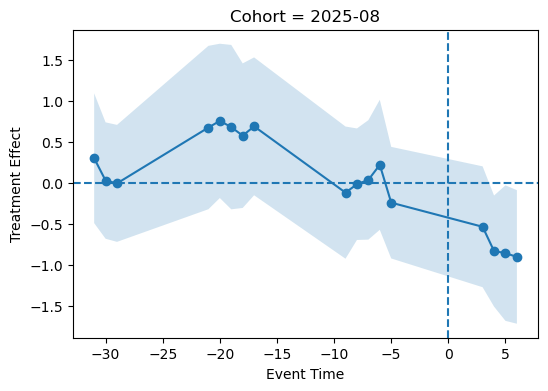

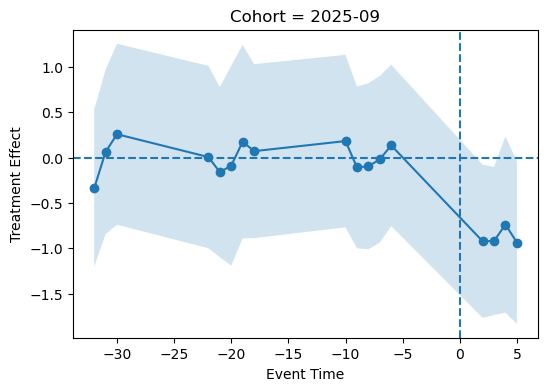

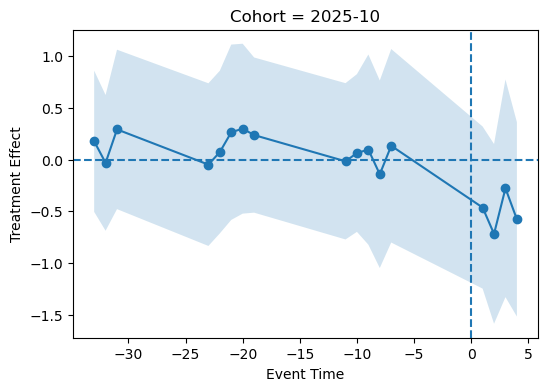

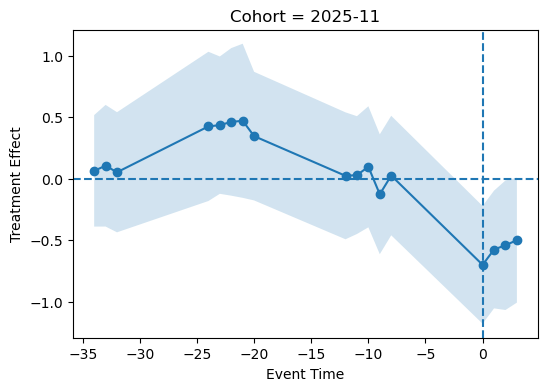

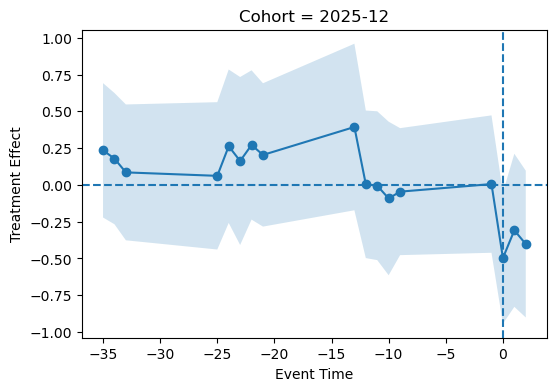

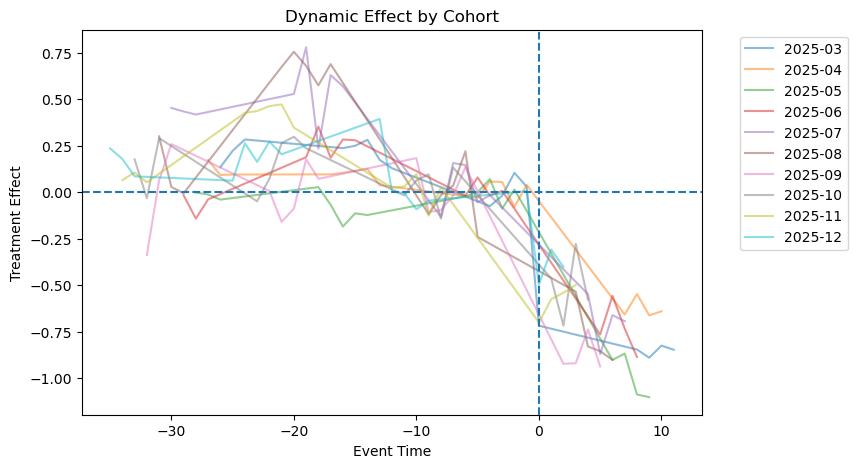


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -0.8253 0.0288 -28.6387   0.0000 -0.8818  -0.7689          5
1  2025-04 -0.6272 0.0269 -23.3546   0.0000 -0.6798  -0.5745          4
2  2025-05 -0.9901 0.0611 -16.2088   0.0000 -1.1098  -0.8704          4
3  2025-06 -0.7356 0.0678 -10.8449   0.0000 -0.8686  -0.6027          4
4  2025-07 -0.6935 0.0668 -10.3799   0.0000 -0.8244  -0.5625          4
5  2025-08 -0.7804 0.0833  -9.3725   0.0000 -0.9436  -0.6172          4
6  2025-09 -0.8795 0.0473 -18.6135   0.0000 -0.9721  -0.7869          4
7  2025-10 -0.5093 0.0930  -5.4782   0.0000 -0.6915  -0.3271          4
8  2025-11 -0.5792 0.0433 -13.3694   0.0000 -0.6642  -0.4943          4
9  2025-12 -0.4026 0.0544  -7.3995   0.0000 -0.5092  -0.2959          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-10 -0.5908 0.1271  -4.6480   0.000

In [12]:
df_high = df[df["price"]== "high"] 
run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_high")

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 15, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.4359        5.3188  0.1171 0.2685  0.4362   0.6627   
1          -34        5.8549        5.4987  0.3562 0.2121  1.6798   0.0930   
2          -33        5.9161        5.5221  0.3939 0.1994  1.9760   0.0481   
3          -32        5.6449        5.4388  0.2061 0.1893  1.0891   0.2761   
4          -31        5.3000        4.9234  0.3766 0.1770  2.1276   0.0334   
5          -30        5.0478        4.5652  0.4826 0.1609  2.9997   0.0027   
6          -29        5.1316        4.5678  0.5638 0.1509  3.7355   0.0002   
7          -28        5.0651        4.6433  0.4218 0.1285  3.2818   0.0010   
8          -27        5.2364        4.7317  0.5047 0.1066  4.7339   0.0000   
9          -26        5.7963        5.0560  0.7402 0.0876  8.4488   0.0000   
10         -25        5.9034        5.1326  0.7708 0.0912  8.4473   0.0000   
11         -

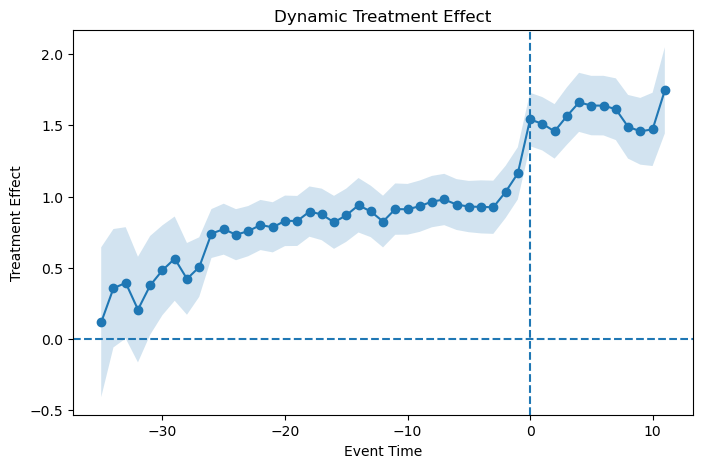


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.9534767929039519, 't_stat': 40.40786655460433, 'p_value': 2.5889085530639524e-13}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.5658090577941508, 'SE': 0.026956113121625155, 't_stat': 58.08734555791736, 'p_value': 0.0, 'CI_low': 1.5129750760757654, 'CI_high': 1.6186430395125362, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.5031389198100689, 'SE': 0.02437959342253543, 't_stat': 61.65561885132313, 'p_value': 0.0, 'CI_low': 1.4553549167018995, 'CI_high': 1.5509229229182382, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  1.0778 0.1459  7.3890   0.0000        620   
1    2025-03         -25  1.1875 0.1502  7.9052   0.0000        620   
2    2025-03         -24  1.1523 0.1509  7.6339   0.0000        617   
3    2025-03         -23  1.0

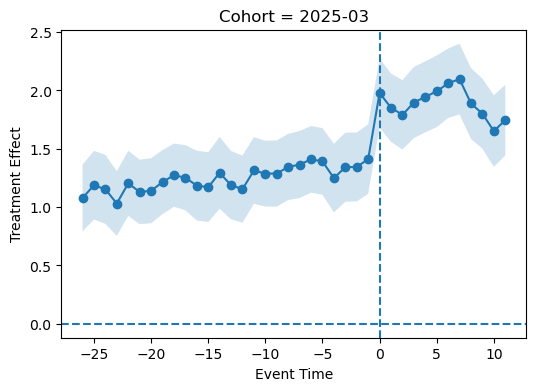

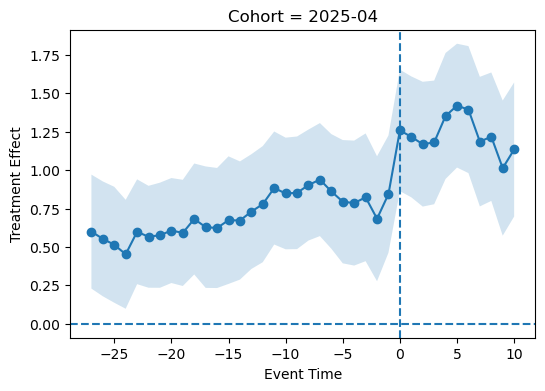

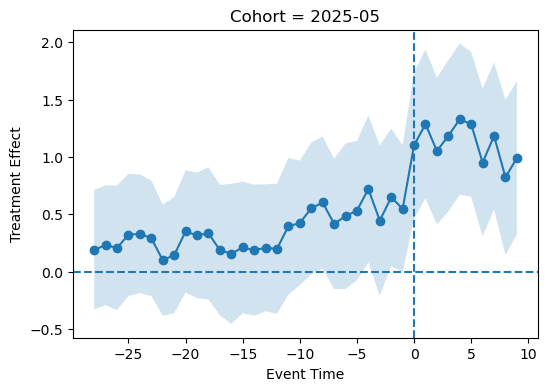

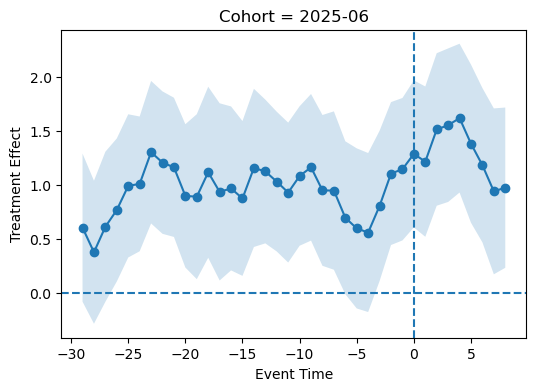

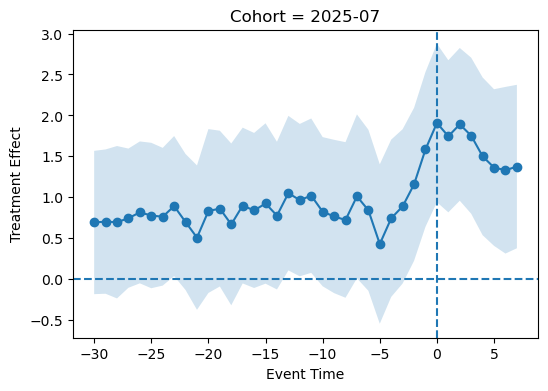

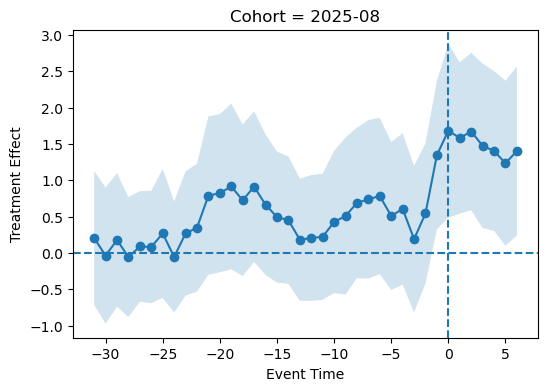

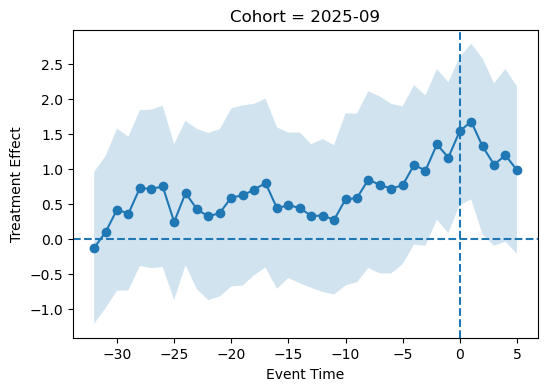

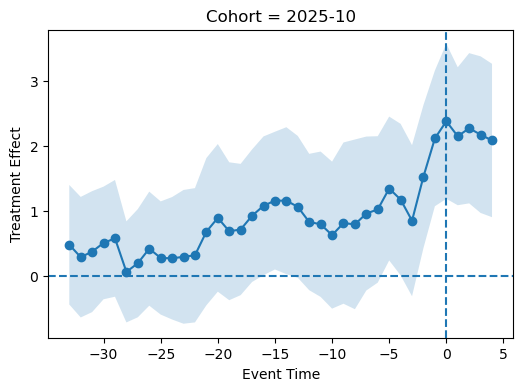

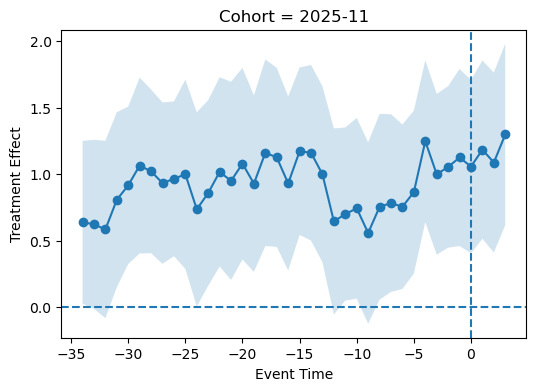

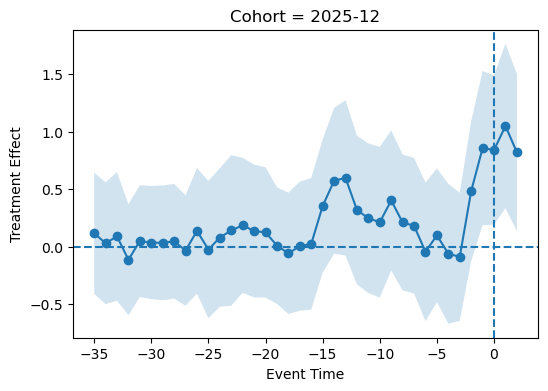

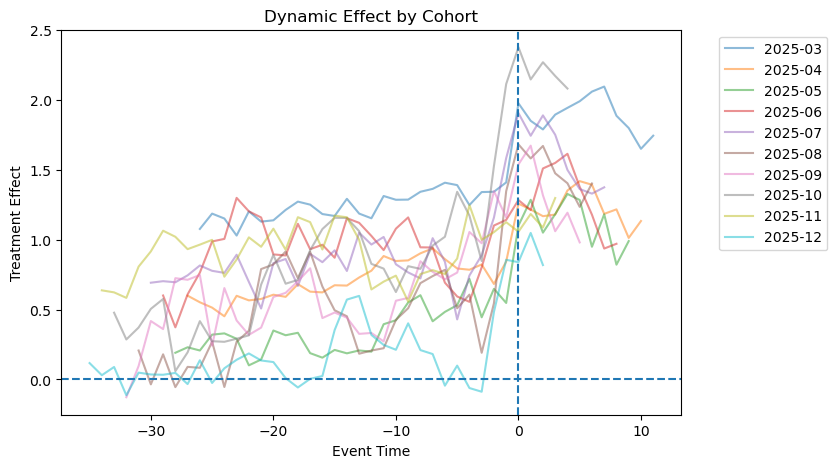


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.8915 0.0380 49.7768   0.0000  1.8170   1.9659         12
1  2025-04 1.2314 0.0361 34.0836   0.0000  1.1605   1.3022         11
2  2025-05 1.1182 0.0523 21.3958   0.0000  1.0158   1.2206         10
3  2025-06 1.2936 0.0812 15.9315   0.0000  1.1344   1.4527          9
4  2025-07 1.6083 0.0857 18.7572   0.0000  1.4403   1.7764          8
5  2025-08 1.4941 0.0614 24.3224   0.0000  1.3737   1.6145          7
6  2025-09 1.2948 0.1107 11.7016   0.0000  1.0780   1.5117          6
7  2025-10 2.2111 0.0518 42.7037   0.0000  2.1096   2.3126          5
8  2025-11 1.1573 0.0545 21.2281   0.0000  1.0505   1.2642          4
9  2025-12 0.9026 0.0735 12.2823   0.0000  0.7586   1.0467          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.8734 0.0551 33.9823   0.0000  1.7653   1.9814        

In [13]:
df_all = df[df["price"]== "all"] 
run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_all")

StatementMeta(, aeb193eb-33bb-4580-af79-9b79db7cad1b, 16, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.1893        5.0742  0.1152 0.2640  0.4362   0.6627   
1          -34        5.5685        5.2029  0.3656 0.2111  1.7320   0.0833   
2          -33        5.6504        5.2137  0.4367 0.1988  2.1965   0.0281   
3          -32        5.4765        5.1987  0.2778 0.1870  1.4858   0.1373   
4          -31        5.2005        4.8151  0.3854 0.1758  2.1920   0.0284   
5          -30        4.9566        4.4609  0.4956 0.1592  3.1134   0.0018   
6          -29        5.0454        4.4581  0.5874 0.1504  3.9056   0.0001   
7          -28        4.9649        4.5097  0.4552 0.1280  3.5554   0.0004   
8          -27        5.1166        4.5697  0.5469 0.1062  5.1494   0.0000   
9          -26        5.6511        4.8598  0.7913 0.0873  9.0608   0.0000   
10         -25        5.7639        4.9341  0.8298 0.0912  9.1028   0.0000   
11         -

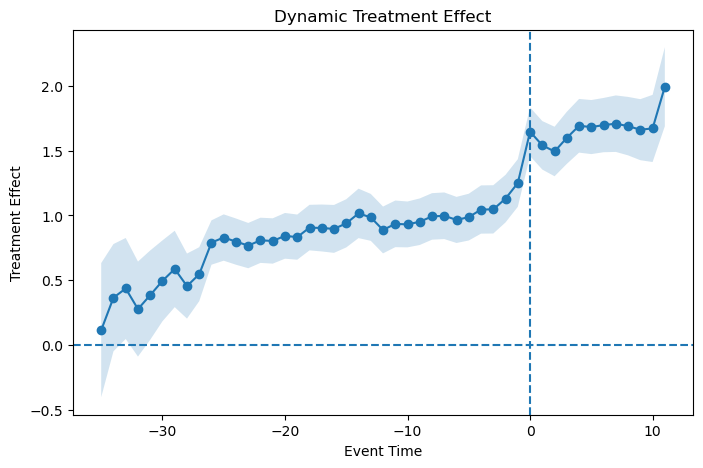


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 1.0102802757420257, 't_stat': 35.330031268414324, 'p_value': 1.122317875175733e-12}

===== OVERALL ATT: ALL POST PERIODS =====
{'ATT': 1.6729970864816883, 'SE': 0.03492779113410795, 't_stat': 47.89873714195344, 'p_value': 0.0, 'CI_low': 1.6045386158588368, 'CI_high': 1.7414555571045398, 'n_periods': 12}

===== OVERALL ATT: FIRST 3 POST PERIODS =====
{'ATT': 1.560355077595031, 'SE': 0.04504778675100773, 't_stat': 34.637774464249915, 'p_value': 0.0, 'CI_low': 1.4720614155630558, 'CI_high': 1.6486487396270062, 'n_periods': 3}

===== COHORT DYNAMIC EFFECT =====

Cohort dynamic effect:
      cohort  event_time  effect     se  t_stat  p_value  n_treated  \
0    2025-03         -26  1.1902 0.1465  8.1263   0.0000        620   
1    2025-03         -25  1.3033 0.1509  8.6370   0.0000        620   
2    2025-03         -24  1.2979 0.1524  8.5154   0.0000        617   
3    2025-03         -23  1.03

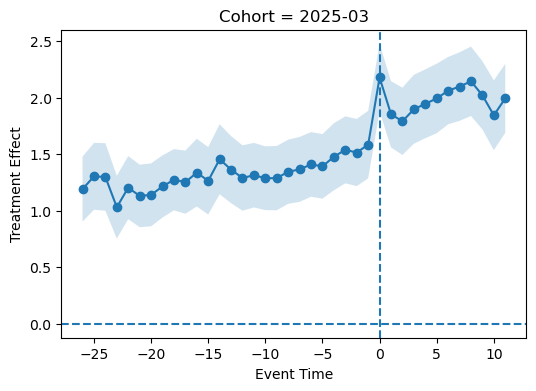

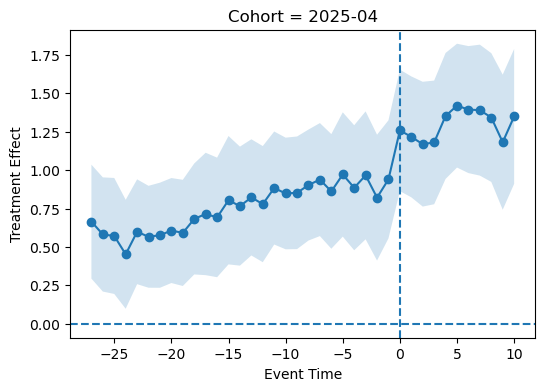

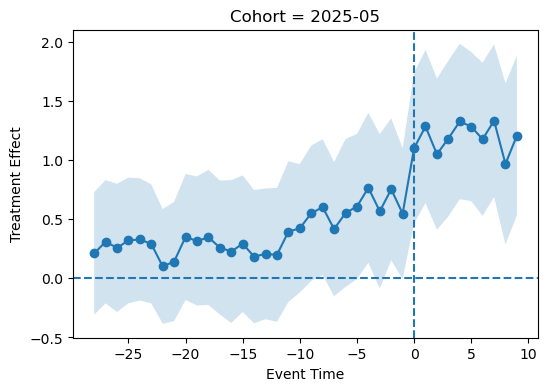

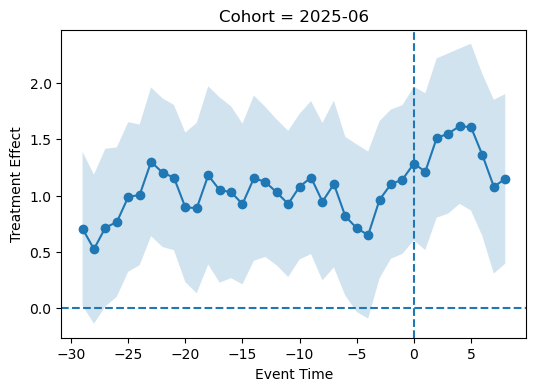

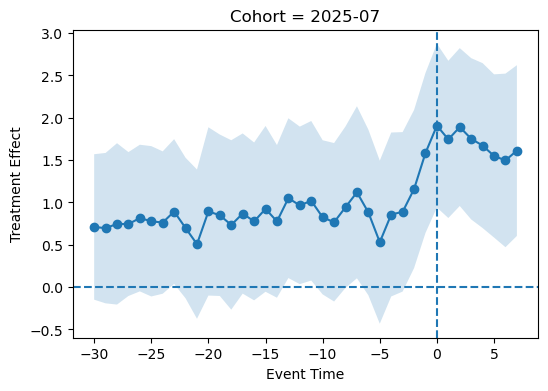

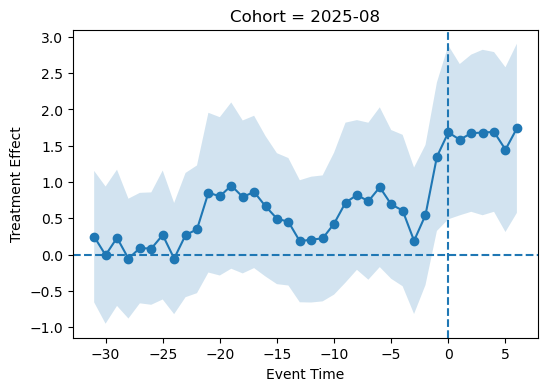

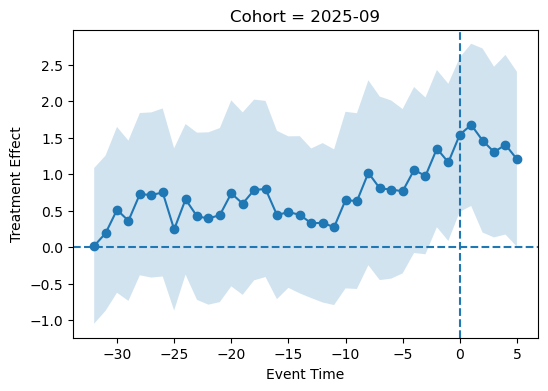

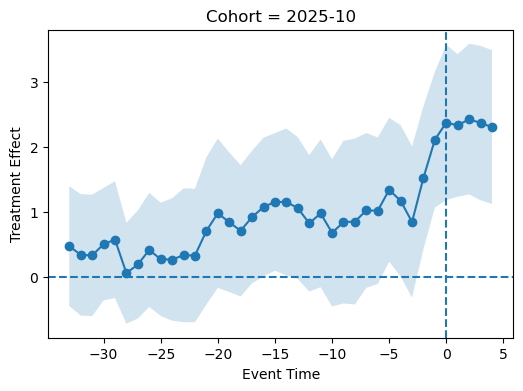

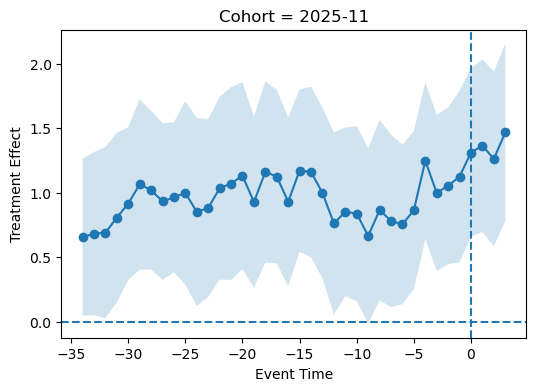

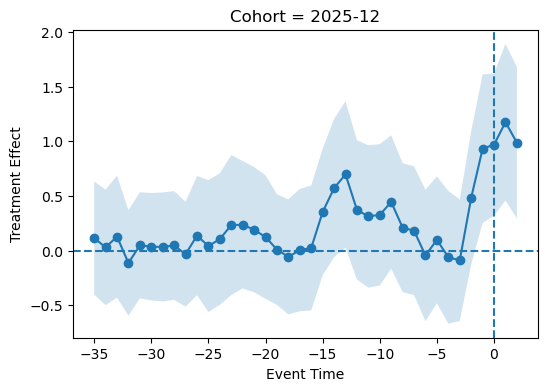

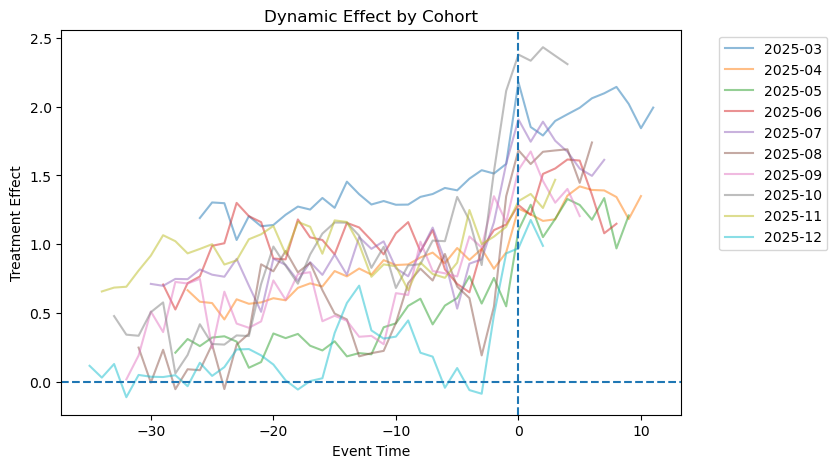


===== ATT BY COHORT: ALL POST PERIODS =====
    cohort    ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.9844 0.0356  55.7594   0.0000  1.9146   2.0541         12
1  2025-04 1.2962 0.0290  44.7233   0.0000  1.2394   1.3530         11
2  2025-05 1.1927 0.0387  30.8091   0.0000  1.1168   1.2686         10
3  2025-06 1.3744 0.0682  20.1462   0.0000  1.2407   1.5081          9
4  2025-07 1.7035 0.0528  32.2366   0.0000  1.6000   1.8071          8
5  2025-08 1.6422 0.0371  44.2119   0.0000  1.5694   1.7150          7
6  2025-09 1.4302 0.0685  20.8819   0.0000  1.2960   1.5644          6
7  2025-10 2.3651 0.0210 112.6480   0.0000  2.3240   2.4063          5
8  2025-11 1.3524 0.0439  30.8013   0.0000  1.2664   1.4385          4
9  2025-12 1.0447 0.0659  15.8553   0.0000  0.9155   1.1738          3

===== ATT BY COHORT: FIRST 3 POST PERIODS =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 1.9400 0.1201 16.1518   0.0000  1.7046   2.1

In [14]:
df_low = df[df["price"]== "low"] 
run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching_high/{match_method}_low")